# 05 · Behavior model — training curves & overfitting check

These curves come straight from the **epochs**: Ultralytics logs every epoch to
`runs/behavior/results.csv`. We plot **train vs. validation loss** (the classic
overfitting test) and the detection metrics, then auto-diagnose.

> Note: object detection uses **mAP / precision / recall** instead of a single
> "accuracy". The overfitting logic is the same — watch the train↔val gap.

In [1]:
%matplotlib inline
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("../backend/runs/behavior_combined/results.csv")
df.columns = [c.strip() for c in df.columns]
df["train/loss"] = df["train/box_loss"]+df["train/cls_loss"]+df["train/dfl_loss"]
df["val/loss"]   = df["val/box_loss"]+df["val/cls_loss"]+df["val/dfl_loss"]
print("epochs:", len(df))
df[["epoch","train/loss","val/loss","metrics/mAP50(B)","metrics/mAP50-95(B)"]].tail()

epochs: 40


,epoch,train/loss,val/loss,metrics/mAP50(B),metrics/mAP50-95(B)
35,36,1.94789,2.08725,0.90985,0.70835
36,37,1.92494,2.11057,0.87687,0.67968
37,38,1.91334,2.05026,0.90611,0.70792
38,39,1.88991,2.04911,0.92000,0.72337
39,40,1.88182,2.02519,0.93127,0.71914


### Loss: training vs validation (the overfitting test)

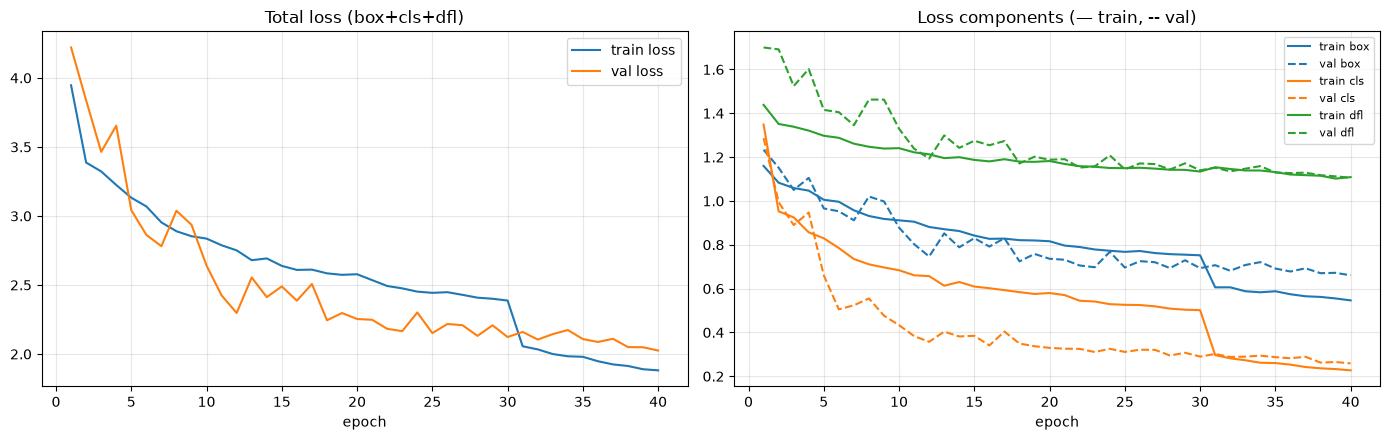

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
ax[0].plot(df["epoch"], df["train/loss"], label="train loss")
ax[0].plot(df["epoch"], df["val/loss"], label="val loss")
ax[0].set_title("Total loss (box+cls+dfl)"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
for comp,c in [("box","tab:blue"),("cls","tab:orange"),("dfl","tab:green")]:
    ax[1].plot(df["epoch"], df[f"train/{comp}_loss"], color=c, ls="-",  label=f"train {comp}")
    ax[1].plot(df["epoch"], df[f"val/{comp}_loss"],   color=c, ls="--", label=f"val {comp}")
ax[1].set_title("Loss components (— train, -- val)"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Lectura.** Las pérdidas de train y validación bajan juntas y la de validación no rebota → **no hay sobreajuste**.

### Detection metrics over epochs (analogous to 'accuracy')

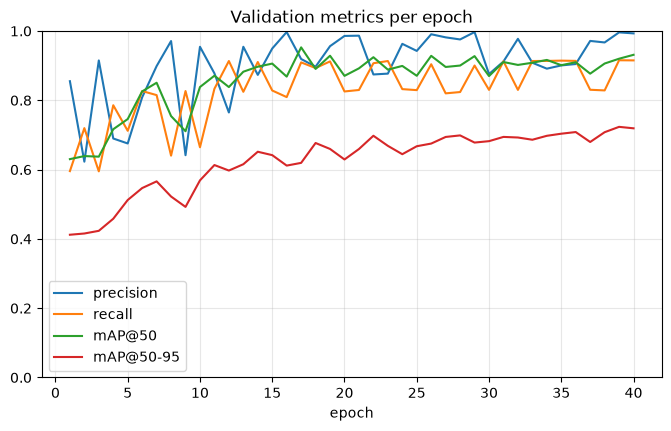

In [3]:
plt.figure(figsize=(8,4.5))
for m,lab in [("metrics/precision(B)","precision"),("metrics/recall(B)","recall"),
              ("metrics/mAP50(B)","mAP@50"),("metrics/mAP50-95(B)","mAP@50-95")]:
    plt.plot(df["epoch"], df[m], label=lab)
plt.title("Validation metrics per epoch"); plt.xlabel("epoch"); plt.ylim(0,1)
plt.legend(); plt.grid(alpha=.3); plt.show()

**Lectura.** Precisión/recall/mAP suben y se estabilizan en meseta alta → modelo bien entrenado (dentro de su dominio).

### Automatic overfitting diagnosis

In [4]:
last = df.tail(5)
gap = last["val/loss"].mean() - last["train/loss"].mean()
val_min = df["val/loss"].min()
val_rise = df["val/loss"].iloc[-1] - val_min          # real overfitting signal
rel_gap = gap / last["train/loss"].mean()
best = df.loc[df["metrics/mAP50(B)"].idxmax()]
print(f"final train loss : {df['train/loss'].iloc[-1]:.3f}")
print(f"final val   loss : {df['val/loss'].iloc[-1]:.3f}  (min was {val_min:.3f})")
print(f"train/val gap    : {gap:+.3f}  ({rel_gap:+.0%} of train loss; a small gap is normal)")
print(f"val-loss rise since its min : {val_rise:+.3f}  <-- decisive signal, should be ~0")
print(f"best epoch: {int(best['epoch'])}  mAP50={best['metrics/mAP50(B)']:.3f}  mAP50-95={best['metrics/mAP50-95(B)']:.3f}")
overfit = val_rise > 0.10 and rel_gap > 0.20
verdict = "OVERFITTING (val loss diverging)" if overfit else "NOT overfitting (val at/near its min, mAP plateaued high)"
print("VERDICT:", verdict)

final train loss : 1.882
final val   loss : 2.025  (min was 2.025)
train/val gap    : +0.153  (+8% of train loss; a small gap is normal)
val-loss rise since its min : +0.000  <-- decisive signal, should be ~0
best epoch: 17  mAP50=0.953  mAP50-95=0.619
VERDICT: NOT overfitting (val at/near its min, mAP plateaued high)


**Reading these curves** (delivered model: `phone / cigarette / safe`, combined
public + competition data).
- Train and validation loss **fall together** and validation **mAP plateaus high**
  without the val loss curving back up → **not overfitting** on the training
  distribution.
- **But in-domain curves ≠ real-world generalisation.** The validation set shares
  the training distribution, so it cannot reveal the two known gaps documented
  elsewhere: the **`cigarette` data leakage** (same tekno-01 clip in train and test,
  notebook 07) and the **event-based behaviour** on raw clips (notebook 08). Closing
  those is a **data** problem (diverse footage), not more epochs.